#### This notebook uses the HDBSCAN clustering algorithm to divide beaching drifter trajectories into clusters, or watersheds. We select the 12 best, save them, and plot them.
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

In [1]:
# set working directory
import os
os.chdir('/dat1/openonic/Drifters') # directory

In [2]:
# dependencies
import pandas as pd
import scipy.interpolate as sci_int
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sci_stats
import cartopy.crs as ccrs
import geopandas as gpd
import geodatasets

import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap


from sklearn.preprocessing import MinMaxScaler
import hdbscan

from joblib import Parallel, delayed
from fast_histogram import histogram2d

/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# import undrogued data
beach_undrogued = pd.read_csv('undrogued_beach.csv')
unbeach_undrogued = pd.read_csv('undrogued_unbeach.csv')

# import drogued data
beach_full = pd.read_csv('full_beach.csv')
unbeach_full = pd.read_csv('full_unbeach.csv')

In [12]:
# set plotting text size parameters
## set plotting text size parameters
plt.rcParams.update({
    'axes.titlesize': 30,
    'axes.labelsize': 24, 
    'xtick.labelsize': 18,  
    'ytick.labelsize': 18,  
    'legend.fontsize': 12, 
    'legend.title_fontsize':12,
    'figure.titlesize': 30})

In [13]:
# Set the random seed
random_seed = 42
np.random.seed(random_seed)

In [14]:
# select data
beach = beach_full

In [15]:
# get features for clustering and normalize to close to scale of lat/lon with lat/lon weighted for clustering AND RUN HDBSCAN TWICE
# get beach points for beach lat/lon
last_points_input = beach.drop_duplicates(subset='id', keep='last')

# input feature: beach latitude
beach_lat = np.array(last_points_input['lat']).reshape(-1,1)

# input feature: beach longitude
beach_lon = np.array(last_points_input['lon']).reshape(-1,1)

# initialize input
cluster_input = np.column_stack((beach_lat, beach_lon))#, time_normalized, v_avg_normalized))

hdb = hdbscan.HDBSCAN(
    min_cluster_size = 40, # minimum number beach points in a cluster
    cluster_selection_epsilon = 8,# clusters below distance threshold are merged
    cluster_selection_method = 'leaf') 
hdb.fit(cluster_input)
labels = hdb.labels_

#organize dataframe of ids and HDBSCAN cluster labels
cluster_df = pd.DataFrame({'id': last_points_input['id'], 'HDBSCAN': labels})

histogram = plt.hist(cluster_df['HDBSCAN'], bins = len(np.unique(cluster_df['HDBSCAN'])))
plt.close() # do not display histogram
cluster_ids = []
count = np.min(cluster_df['HDBSCAN'])
for i in histogram[0]:
    if i > 0:
        cluster_ids.append(count)
    count += 1

# remove unclustered 'noise' and select clusters
cluster_ids = cluster_ids[1:]
beach_clusters_select = cluster_df[cluster_df['HDBSCAN'].isin(cluster_ids)]

# merge cluster labels with the original data

beach_clusters = pd.merge(beach.set_index('id'), beach_clusters_select.set_index('id'), left_index=True, right_index=True, how='left').reset_index()
beach_clusters = beach_clusters[beach_clusters['id'].isin(beach_clusters_select['id'])]

In [16]:
len(beach_clusters.drop_duplicates(subset='id', keep='last'))

3665

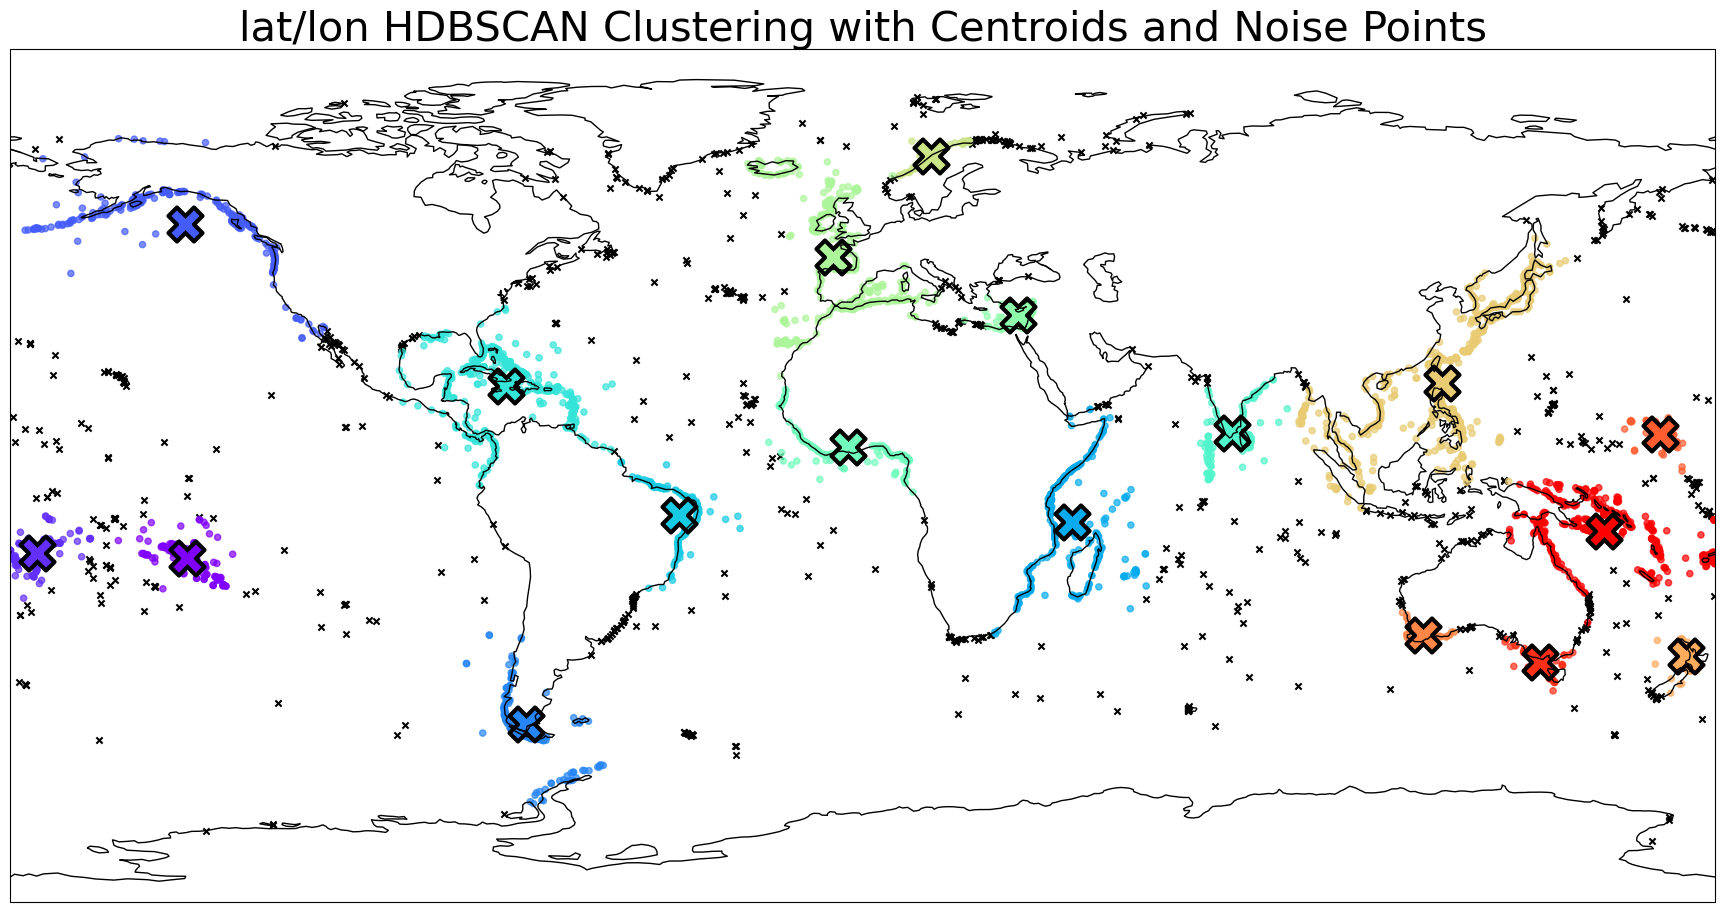

In [17]:
fig = plt.figure(figsize=(22, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
#left right bottom top
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.coastlines()
point_size = 10

# Plot noise points as small 'x'
noise_mask = (labels == -1)
ax.scatter(cluster_input[noise_mask, 1], cluster_input[noise_mask, 0], marker='x', color='black', s=20, label='Noise Points')

# Scatter plot with colors based on HDBSCAN labels
scatter1 = plt.scatter(
    cluster_input[labels != -1, 1],
    cluster_input[labels != -1, 0],
    marker='o',
    c=labels[labels != -1],
    cmap='rainbow',
    alpha=0.7,
    s=20
)

# Plot centroids with the same colors as corresponding points
for cluster_id in set(labels):
    cluster_mask = (labels == cluster_id)

    if cluster_id != -1:
        cluster_points = cluster_input[cluster_mask]
        centroid = np.mean(cluster_points, axis=0)
        color = scatter1.to_rgba(cluster_id)  # Get the color from the first scatter plot
        ax.scatter(centroid[1], centroid[0], marker='X', color=color, edgecolor='black', linewidths=3, s=600, label=f'Cluster {cluster_id} Centroid')

# Get the colors used in the first figure
colors_first_figure = scatter1.to_rgba(scatter1.get_array())

#ax.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('lat/lon HDBSCAN Clustering with Centroids and Noise Points')
plt.show()

In [18]:
# NOW INPUT CLUSTERED DATA INTO NEW HDBSCAN
# get beach points for beach lat/lon
last_points_input = beach_clusters.drop_duplicates(subset='id', keep='last')

# input feature: beach latitude
beach_lat = np.array(last_points_input['lat']).reshape(-1,1)

# input feature: beach longitude
beach_lon = np.array(last_points_input['lon']).reshape(-1,1)

# initialize input
cluster_input = np.column_stack((beach_lat, beach_lon))#, time_normalized, v_avg_normalized))

hdb = hdbscan.HDBSCAN(
    min_cluster_size = 10, # minimum number beach points in a cluster
    cluster_selection_epsilon = 2) # clusters below distance threshold are merged
hdb.fit(cluster_input)
labels = hdb.labels_

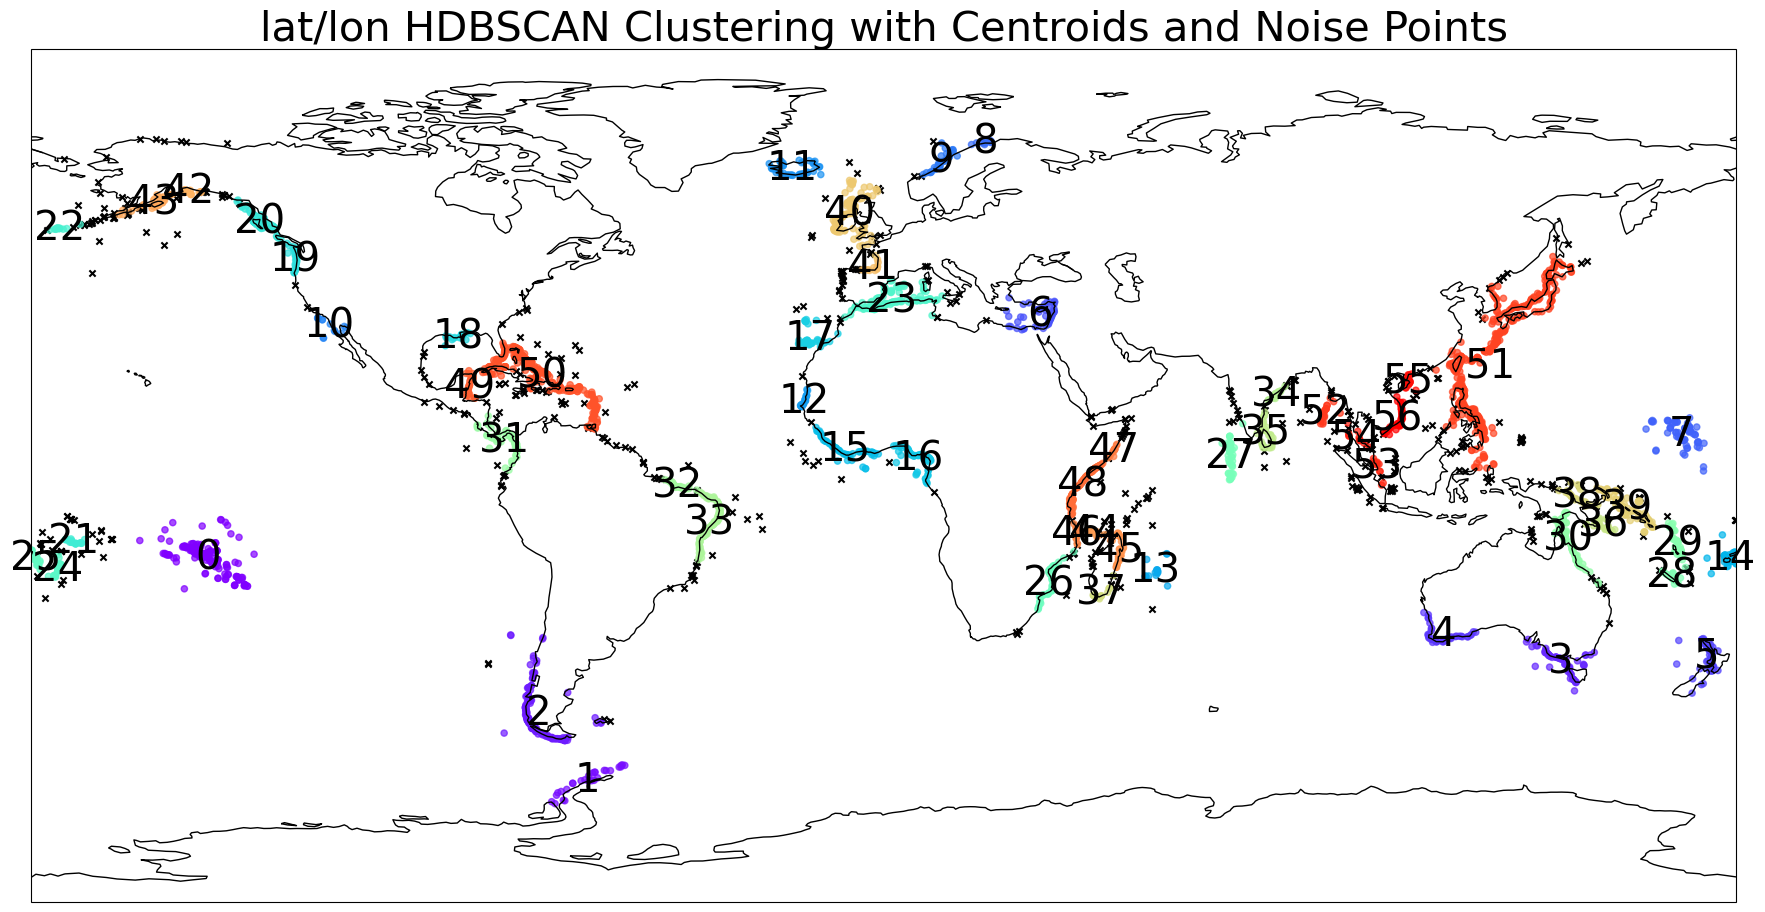

In [19]:
fig = plt.figure(figsize=(22, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
#left right bottom top
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.coastlines()
point_size = 10

# Plot noise points as small 'x'
noise_mask = (labels == -1)
ax.scatter(cluster_input[noise_mask, 1], cluster_input[noise_mask, 0], marker='x', color='black', s=20, label='Noise Points')

# Scatter plot with colors based on HDBSCAN labels
scatter1 = plt.scatter(
    cluster_input[labels != -1, 1],
    cluster_input[labels != -1, 0],
    marker='o',
    c=labels[labels != -1],
    cmap='rainbow',
    alpha=0.7,
    s=20
)

# Plot centroids with the same colors as corresponding points
for cluster_id in set(labels):
    cluster_mask = (labels == cluster_id)

    if cluster_id != -1:
        cluster_points = cluster_input[cluster_mask]
        centroid = np.mean(cluster_points, axis=0)
        color = scatter1.to_rgba(cluster_id)  # Get the color from the first scatter plot
       # ax.scatter(centroid[1], centroid[0], marker='X', color=color, edgecolor='black', linewidths=3, s=600, label=f'Cluster {cluster_id} Centroid')
        # plot label 
        ax.text(centroid[1], centroid[0], str(cluster_id), fontsize=29, ha='center', va='center', color='black')
        
# Get the colors used in the first figure
colors_first_figure = scatter1.to_rgba(scatter1.get_array())

#ax.legend()
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('lat/lon HDBSCAN Clustering with Centroids and Noise Points')
plt.show()

In [20]:
# let's collect clusters into larger clusters, then filter by number of points

# organize dataframe of ids and HDBSCAN cluster labels
cluster_df = pd.DataFrame({'id': last_points_input['id'], 'HDBSCAN': labels})

histogram = plt.hist(cluster_df['HDBSCAN'], bins = len(np.unique(cluster_df['HDBSCAN'])))
plt.close() # do not display histogram
cluster_ids = []
count = np.min(cluster_df['HDBSCAN'])
for i in histogram[0]:
    if i > 0:
        cluster_ids.append(count)
    count += 1
    
# remove unclustered 'noise' and select clusters
cluster_ids = cluster_ids[1:]
beach_clusters_select = cluster_df[cluster_df['HDBSCAN'].isin(cluster_ids)]

def get_cluster_ids(cluster_ids,dataframe):
    ids = []
    for cluster in cluster_ids:
        ids.extend(np.array([id for id in dataframe['id'].where(dataframe['HDBSCAN'] == cluster).dropna()]))
    return ids
watersheds={
    'N_Pacific': get_cluster_ids([22,43,42,19,20,10],beach_clusters_select),
    'W_Pacific': get_cluster_ids([51,55,56,53,7],beach_clusters_select),
    'SW_Pacific': get_cluster_ids([21,25,24,38,28,30,29,36,39,14],beach_clusters_select),
    'N_Indian': get_cluster_ids([27,35,34,52],beach_clusters_select),
    'W_Indian': get_cluster_ids([47,48,44,64,45,13,26,37],beach_clusters_select),
    'SE_Atlantic': get_cluster_ids([12,15,16],beach_clusters_select),
    'NE_Atlantic': get_cluster_ids([11,40,41,9,8,17],beach_clusters_select),
    'NW_Atlantic': get_cluster_ids([18,49,50],beach_clusters_select),
    'Southern_Ocean_Oceania': get_cluster_ids([4,3,5],beach_clusters_select),
    'Central_Pacific': get_cluster_ids([0],beach_clusters_select),
    'SW_Atlantic': get_cluster_ids([32,33],beach_clusters_select),
    'Southern_Ocean_S_America': get_cluster_ids([2,1],beach_clusters_select),
    'Mediterranean': get_cluster_ids([23,6],beach_clusters_select)
}



In [21]:
for watershed in watersheds:
    print(len(watersheds[str(watershed)]))

174
588
413
112
256
148
267
363
163
155
147
161
178


/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:1692: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  result = super().scatter(*args, **kwargs)
/home/openonic/.conda/envs/drifter_env/lib/python3.11/site-packages/cartopy/

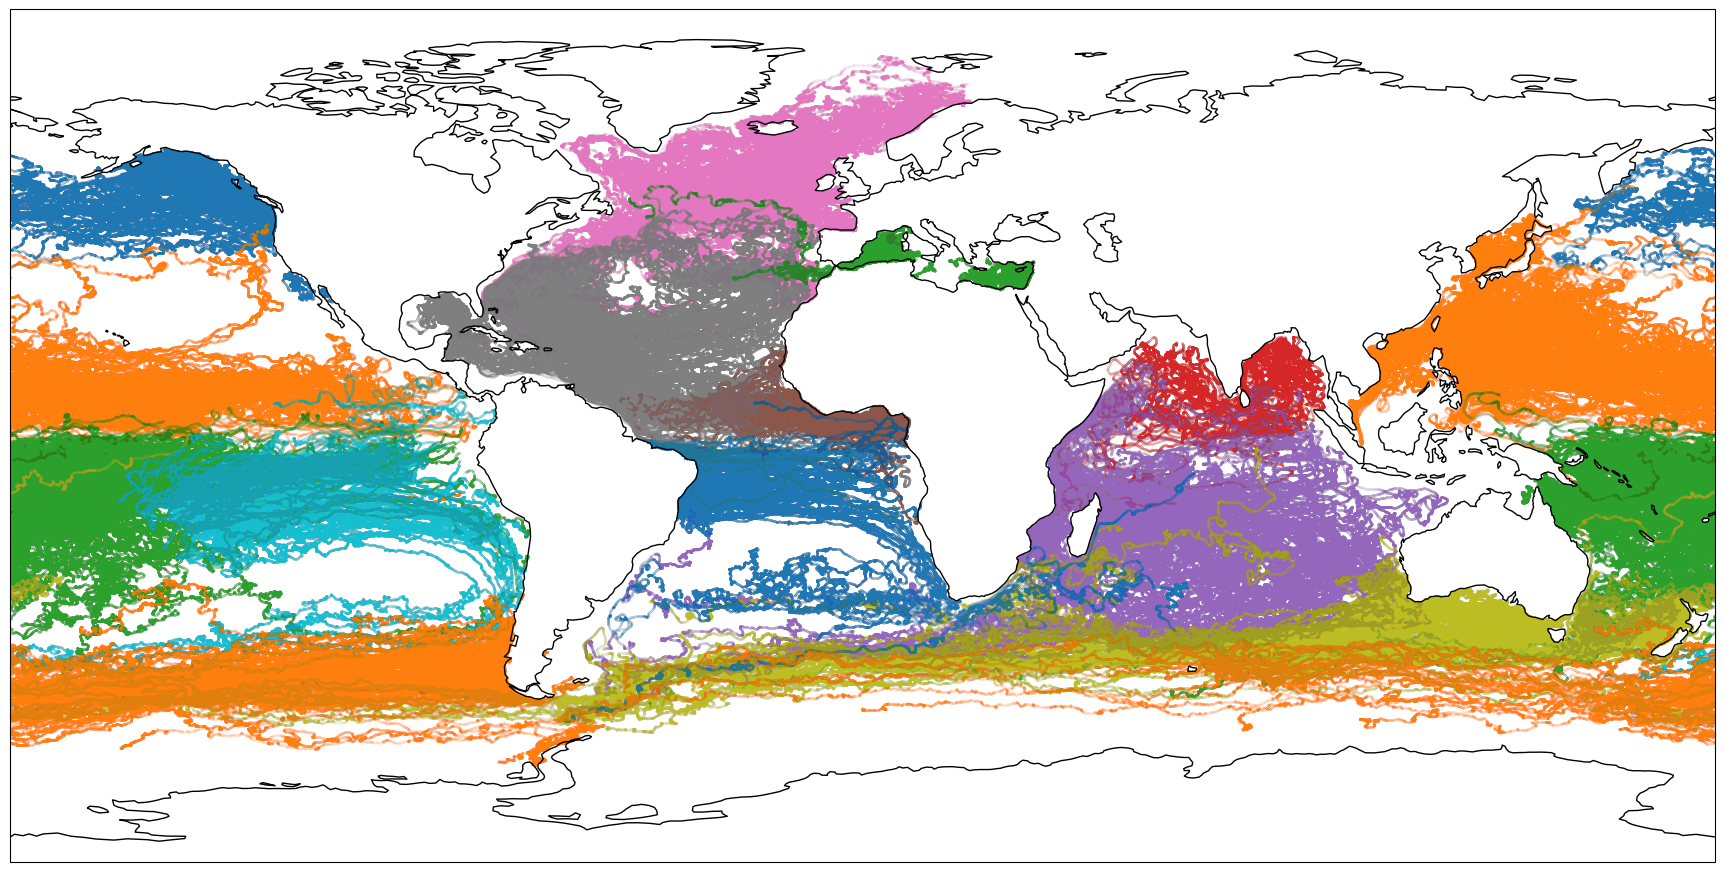

In [22]:
fig = plt.figure(figsize=(22, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
#left right bottom top
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.coastlines()
point_size = 10

# Plot noise points as small 'x'
#noise_mask = (labels == -1)
#ax.scatter(cluster_input[noise_mask, 1], cluster_input[noise_mask, 0], marker='x', color='black', s=20, label='Noise Points')

# Scatter plot with colors based on HDBSCAN labels
for watershed in watersheds:
    scatter1 = plt.scatter(
        beach[beach['id'].isin(watersheds[str(watershed)])]['lon'],
        beach[beach['id'].isin(watersheds[str(watershed)])]['lat'],
        marker='o',
      #  c=labels[labels != -1],
        cmap='rainbow',
        alpha=0.7,
        s=0.001
    )

# Plot centroids with the same colors as corresponding points
#for cluster_id in set(labels):
#    cluster_mask = (labels == cluster_id)#

#    if cluster_id != -1:
#        cluster_points = cluster_input[cluster_mask]
#        centroid = np.mean(cluster_points, axis=0)
#        color = scatter1.to_rgba(cluster_id)  # Get the color from the first scatter plot
#       # ax.scatter(centroid[1], centroid[0], marker='X', color=color, edgecolor='black', linewidths=3, s=600, label=f'Cluster {cluster_id} Centroid')
#        # plot label 
#        ax.text(centroid[1], centroid[0], str(cluster_id), fontsize=29, ha='center', va='center', color='black')
        
# Get the colors used in the first figure
colors_first_figure = scatter1.to_rgba(scatter1.get_array())

#ax.legend()
#plt.xlabel('Longitude')
#plt.ylabel('Latitude')
#plt.title('selected clusters')
plt.show()

In [23]:
os.chdir('/home/openonic/global-drifter-program/new')

In [24]:
# save files
for watershed_name, ids in watersheds.items():
    pd.DataFrame(ids).astype(int).to_csv(f'full_watersheds/{watershed_name}_ids.csv', index=False)

In [25]:
N_Pacific_ids = np.array(pd.read_csv('full_watersheds/N_Pacific_ids.csv')).flatten().flatten()
N_Indian_ids = np.array(pd.read_csv('full_watersheds/N_Indian_ids.csv')).flatten().flatten()
W_Indian_ids = np.array(pd.read_csv('full_watersheds/W_Indian_ids.csv')).flatten().flatten()
Southern_Ocean_Oceania_ids = np.array(pd.read_csv('full_watersheds/Southern_Ocean_Oceania_ids.csv')).flatten().flatten()
W_Pacific_ids = np.array(pd.read_csv('full_watersheds/W_Pacific_ids.csv')).flatten().flatten()
NW_Atlantic_ids = np.array(pd.read_csv('full_watersheds/NW_Atlantic_ids.csv')).flatten().flatten()
Central_Pacific_ids = np.array(pd.read_csv('full_watersheds/Central_Pacific_ids.csv')).flatten().flatten()
SE_Atlantic_ids = np.array(pd.read_csv('full_watersheds/SE_Atlantic_ids.csv')).flatten().flatten()
SW_Pacific_ids = np.array(pd.read_csv('full_watersheds/SW_Pacific_ids.csv')).flatten().flatten()
SW_Atlantic_ids = np.array(pd.read_csv('full_watersheds/SW_Atlantic_ids.csv')).flatten().flatten()
Southern_Ocean_S_America_ids = np.array(pd.read_csv('full_watersheds/Southern_Ocean_S_America_ids.csv')).flatten().flatten()
NE_Atlantic_ids = np.array(pd.read_csv('full_watersheds/NE_Atlantic_ids.csv')).flatten().flatten()
#Mediterranean_ids = np.array(pd.read_csv('full_watersheds/Mediterranean_ids.csv')).flatten().flatten()

In [26]:
watersheds = {
    'N_Pacific': beach[beach['id'].isin(N_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'N_Indian': beach[beach['id'].isin(N_Indian_ids)][['id','lat', 'lon','time_to_beach']],
    'W_Indian': beach[beach['id'].isin(W_Indian_ids)][['id','lat', 'lon','time_to_beach']],
    'Southern_Ocean_Oceania': beach[beach['id'].isin(Southern_Ocean_Oceania_ids)][['id','lat', 'lon','time_to_beach']],
    'W_Pacific': beach[beach['id'].isin(W_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'NW_Atlantic': beach[beach['id'].isin(NW_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'Central_Pacific': beach[beach['id'].isin(Central_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'SE_Atlantic': beach[beach['id'].isin(SE_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'SW_Pacific': beach[beach['id'].isin(SW_Pacific_ids)][['id','lat', 'lon','time_to_beach']],
    'SW_Atlantic': beach[beach['id'].isin(SW_Atlantic_ids)][['id','lat', 'lon','time_to_beach']],
    'Southern_Ocean_S_America': beach[beach['id'].isin(Southern_Ocean_S_America_ids)][['id','lat', 'lon','time_to_beach']],
    'NE_Atlantic': beach[beach['id'].isin(NE_Atlantic_ids)][['id','lat', 'lon','time_to_beach']]#,
#    'Mediterranean': beach[beach['id'].isin(Mediterranean_ids)][['id','lat', 'lon','time_to_beach']]
}

In [27]:
beaching_points = beach.loc[beach.groupby('id')['time_to_beach'].idxmin()]

In [28]:
beaching_coooords = (np.array(beaching_points['lat']),np.array(beaching_points['lon']))

In [29]:
N_Pacific_beach = beaching_points[beaching_points['id'].isin(watersheds['N_Pacific']['id'])][['lat', 'lon']]
N_Indian_beach = beaching_points[beaching_points['id'].isin(watersheds['N_Indian']['id'])][['lat', 'lon']]
W_Indian_beach = beaching_points[beaching_points['id'].isin(watersheds['W_Indian']['id'])][['lat', 'lon']]
Southern_Ocean_Oceania_beach = beaching_points[beaching_points['id'].isin(watersheds['Southern_Ocean_Oceania']['id'])][['lat', 'lon']]
W_Pacific_beach = beaching_points[beaching_points['id'].isin(watersheds['W_Pacific']['id'])][['lat', 'lon']]
NW_Atlantic_beach = beaching_points[beaching_points['id'].isin(watersheds['NW_Atlantic']['id'])][['lat', 'lon']]
Central_Pacific_beach = beaching_points[beaching_points['id'].isin(watersheds['Central_Pacific']['id'])][['lat', 'lon']]
SE_Atlantic_beach = beaching_points[beaching_points['id'].isin(watersheds['SE_Atlantic']['id'])][['lat', 'lon']]
SW_Pacific_beach = beaching_points[beaching_points['id'].isin(watersheds['SW_Pacific']['id'])][['lat', 'lon']]
SW_Atlantic_beach = beaching_points[beaching_points['id'].isin(watersheds['SW_Atlantic']['id'])][['lat', 'lon']]
Southern_Ocean_S_America_beach = beaching_points[beaching_points['id'].isin(watersheds['Southern_Ocean_S_America']['id'])][['lat', 'lon']]
NE_Atlantic_beach = beaching_points[beaching_points['id'].isin(watersheds['NE_Atlantic']['id'])][['lat', 'lon']]
#Mediterranean_beach = beaching_points[beaching_points['id'].isin(watersheds['Mediterranean']['id'])][['lat', 'lon']]

In [30]:
beaching_dict = {
    'N_Pacific': N_Pacific_beach,
    'N_Indian': N_Indian_beach,
    'W_Indian': W_Indian_beach,
    'Southern_Ocean_Oceania': Southern_Ocean_Oceania_beach,
    'W_Pacific': W_Pacific_beach,
    'NW_Atlantic': NW_Atlantic_beach,
    'Central_Pacific': Central_Pacific_beach,
    'SE_Atlantic': SE_Atlantic_beach,
    'SW_Pacific': SW_Pacific_beach,
    'SW_Atlantic': SW_Atlantic_beach,
    'Southern_Ocean_S_America': Southern_Ocean_S_America_beach,
    'NE_Atlantic': NE_Atlantic_beach#,
#    'Mediterranean': Mediterranean_beach
}

In [31]:
os.chdir('/home/openonic/global-drifter-program/new')

ERROR 1: PROJ: proj_create_from_database: Open of /home/openonic/.conda/envs/drifter_env/share/proj failed


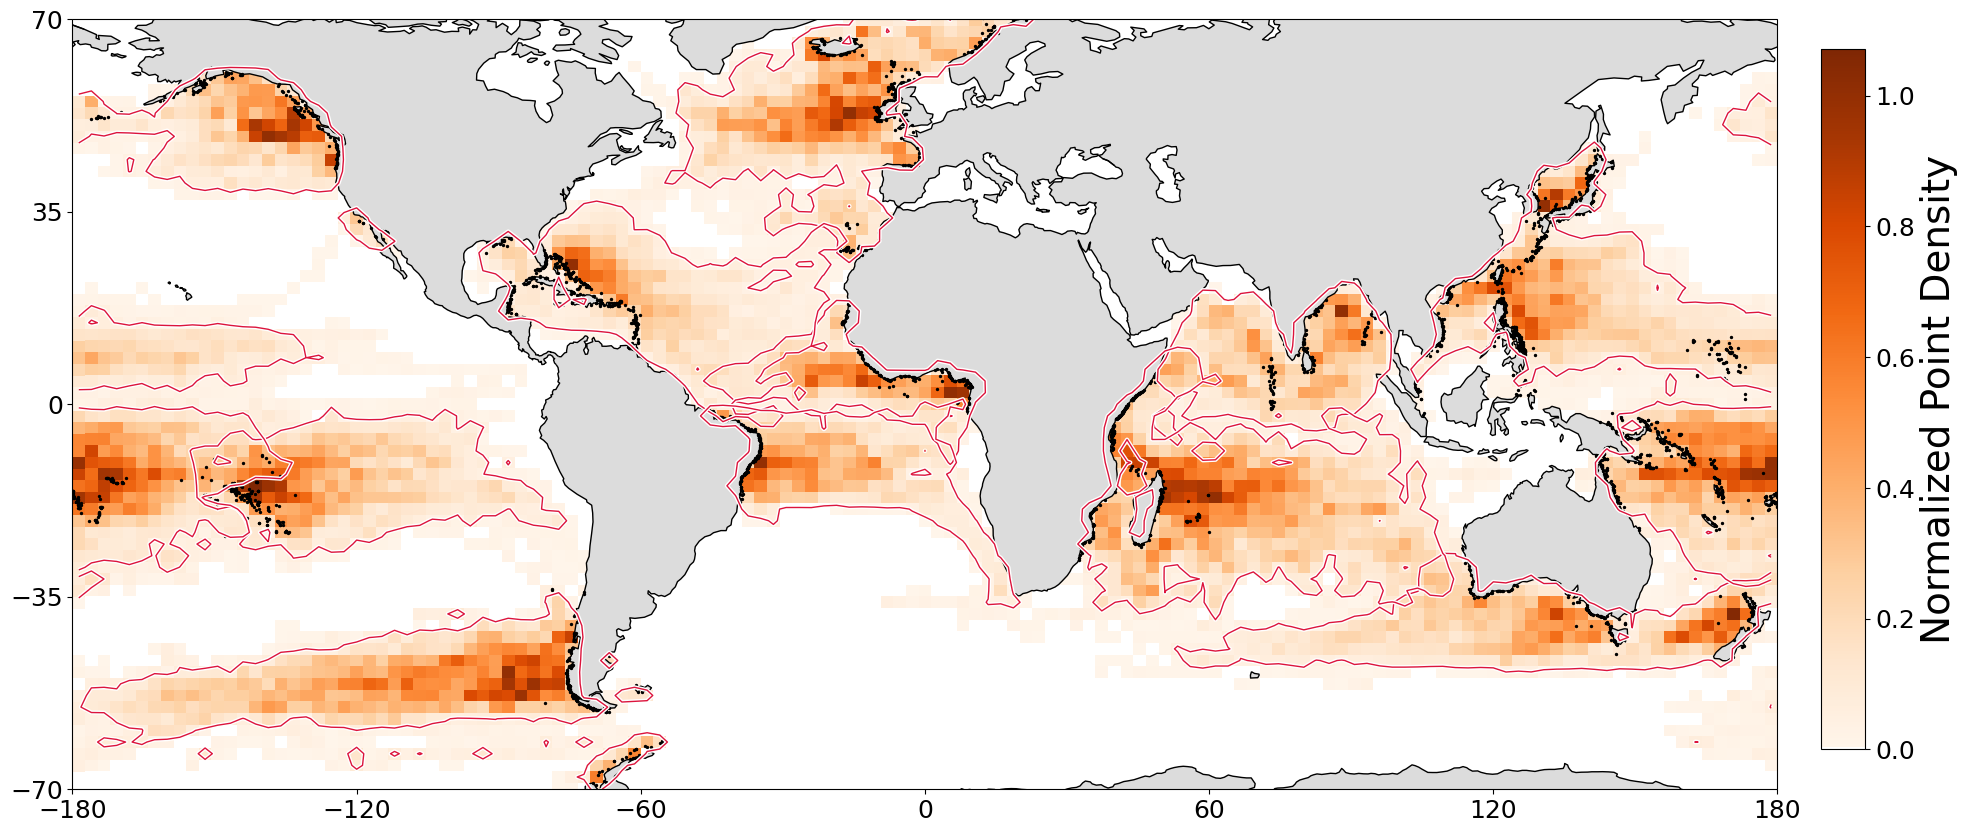

In [35]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)

#grid for the heatmap
n_lons, n_lats = 135, 85  # Number of grid cells
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)
lon_centers_cluster = (lon_bins[1:] + lon_bins[:-1]) / 2
lat_centers_cluster = (lat_bins[1:] + lat_bins[:-1]) / 2

# filter data to within a year
def year_to_beach(cluster):
    year = 31536000  # Number of seconds in 1 year
    # Make a copy of the filtered cluster to avoid the warning
    if (cluster['time_to_beach'] <= year).any():
        filtered_cluster = cluster[cluster['time_to_beach'] <= year].copy()
    return filtered_cluster

def preprocess_data(df):
    # Ensure df is modified safely with .loc and make a copy if needed
    df.loc[:, 'lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df.loc[:, 'lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df.dropna(subset=['lat', 'lon'], inplace=True)
    
    return df

def process_watersheds(watershed_names, watersheds):
    # Create a figure for the plot
    fig = plt.figure(figsize=(22, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)
    # Adjust the position of the plot box for better width control
   # ax.set_position([0.05, 0.05, 0.9, 0.9])  # [left, bottom, width, height]

    cmap = plt.colormaps["Oranges"].resampled(256)

    # Modify the colormap by adding white at the lowest end
    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]  # Set the first color to white (R, G, B, Alpha)

    # Create a new colormap with the modified colors
    custom_cmap = LinearSegmentedColormap.from_list("custom_oranges", new_colors)
    
    contour_handles = []
    
    heatmap_data_normalized12_list = np.zeros((85, 135))
    for j, watershed_name in enumerate(watershed_names):
        # Filter the data for 1 year (12 months) using the new function
        filtered_data_12m = preprocess_data(year_to_beach(watersheds[watershed_name]))
       # print(filtered_data_12m)
        
        latitudes12 = list(filtered_data_12m['lat'].values)
        longitudes12 = list(filtered_data_12m['lon'].values)

        # Calculate the 2D histogram (density plot) of point density for 12 months
        heatmap_data12, _, _ = np.histogram2d(latitudes12, longitudes12, bins=[lat_bins, lon_bins], density=True)

        # Normalize the 12-month data
        heatmap_data_normalized12 = (heatmap_data12 - np.min(heatmap_data12)) / (np.max(heatmap_data12) - np.min(heatmap_data12))

        # Plot contours for the normalized data
        linewidths = [3]
      #  linestyless = ['-', '--', ':', '-.']
        contour = plt.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            #[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)], 
            colors='white', linewidths=linewidths[0], 
            transform=ccrs.PlateCarree()
        )
      #  contour_handles.append(contour.collections[0])
        
        # Add additional contour with crimson color
        contour = plt.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='crimson', linestyles='solid', linewidths=1,
            transform=ccrs.PlateCarree()
        )
      #  contour_handles.append(contour.collections[0])

        heatmap_data_normalized12_list += heatmap_data_normalized12
    # Plot the filled contour for normalized heatmaps
    mesh = ax.pcolormesh(lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12_list, cmap=custom_cmap, transform=ccrs.PlateCarree())

    # Plot the land polygons
    world.plot(ax=ax, color='gainsboro', edgecolor='none')

    # Plot legend
    contour_handles = [
        Line2D([0], [0], color='lightcoral', linewidth=2)
        for watershed in watershed_names
    ]

    for watershed_name in watershed_names:
        plt.scatter(beaching_dict[watershed_name]['lon'], beaching_dict[watershed_name]['lat'], 
                    color='k', s=2)
 #   beach_coords_handle = mlines.Line2D([], [], color='k', marker='o', linestyle='None', markersize=10, label='beach coords')
#
   # ax.legend(contour_handles + [beach_coords_handle], watershed_names + ['beaching locations'], loc='upper right', bbox_to_anchor=(0.83, 1.02), fontsize=18)

    # Add colorbar with increased tick size and label text size
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = plt.colorbar(mesh, cax = cbar_ax, label='Normalized Point Density')
    cbar.ax.tick_params(labelsize=18)  # Increase tick size
    cbar.set_label('Normalized Point Density', size=28)  # Increase label text size
    
    ax.set_aspect('auto')
    
    ax.coastlines(color = 'black')
    
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])
    
    #plt.savefig(f"final_watersheds/watersheds_poster_{'_'.join(watershed_names)}.png")
    
    
# Define combinations of watersheds
combinations = [
    (['NE_Atlantic','N_Indian', 'SE_Atlantic', 'Southern_Ocean_Oceania','W_Pacific','Central_Pacific','NW_Atlantic', 'W_Indian','SW_Pacific', 'SW_Atlantic', 'N_Pacific', 'Southern_Ocean_S_America'], watersheds)
]

for watershed_names, watersheds in combinations:
    process_watersheds(watershed_names, watersheds)

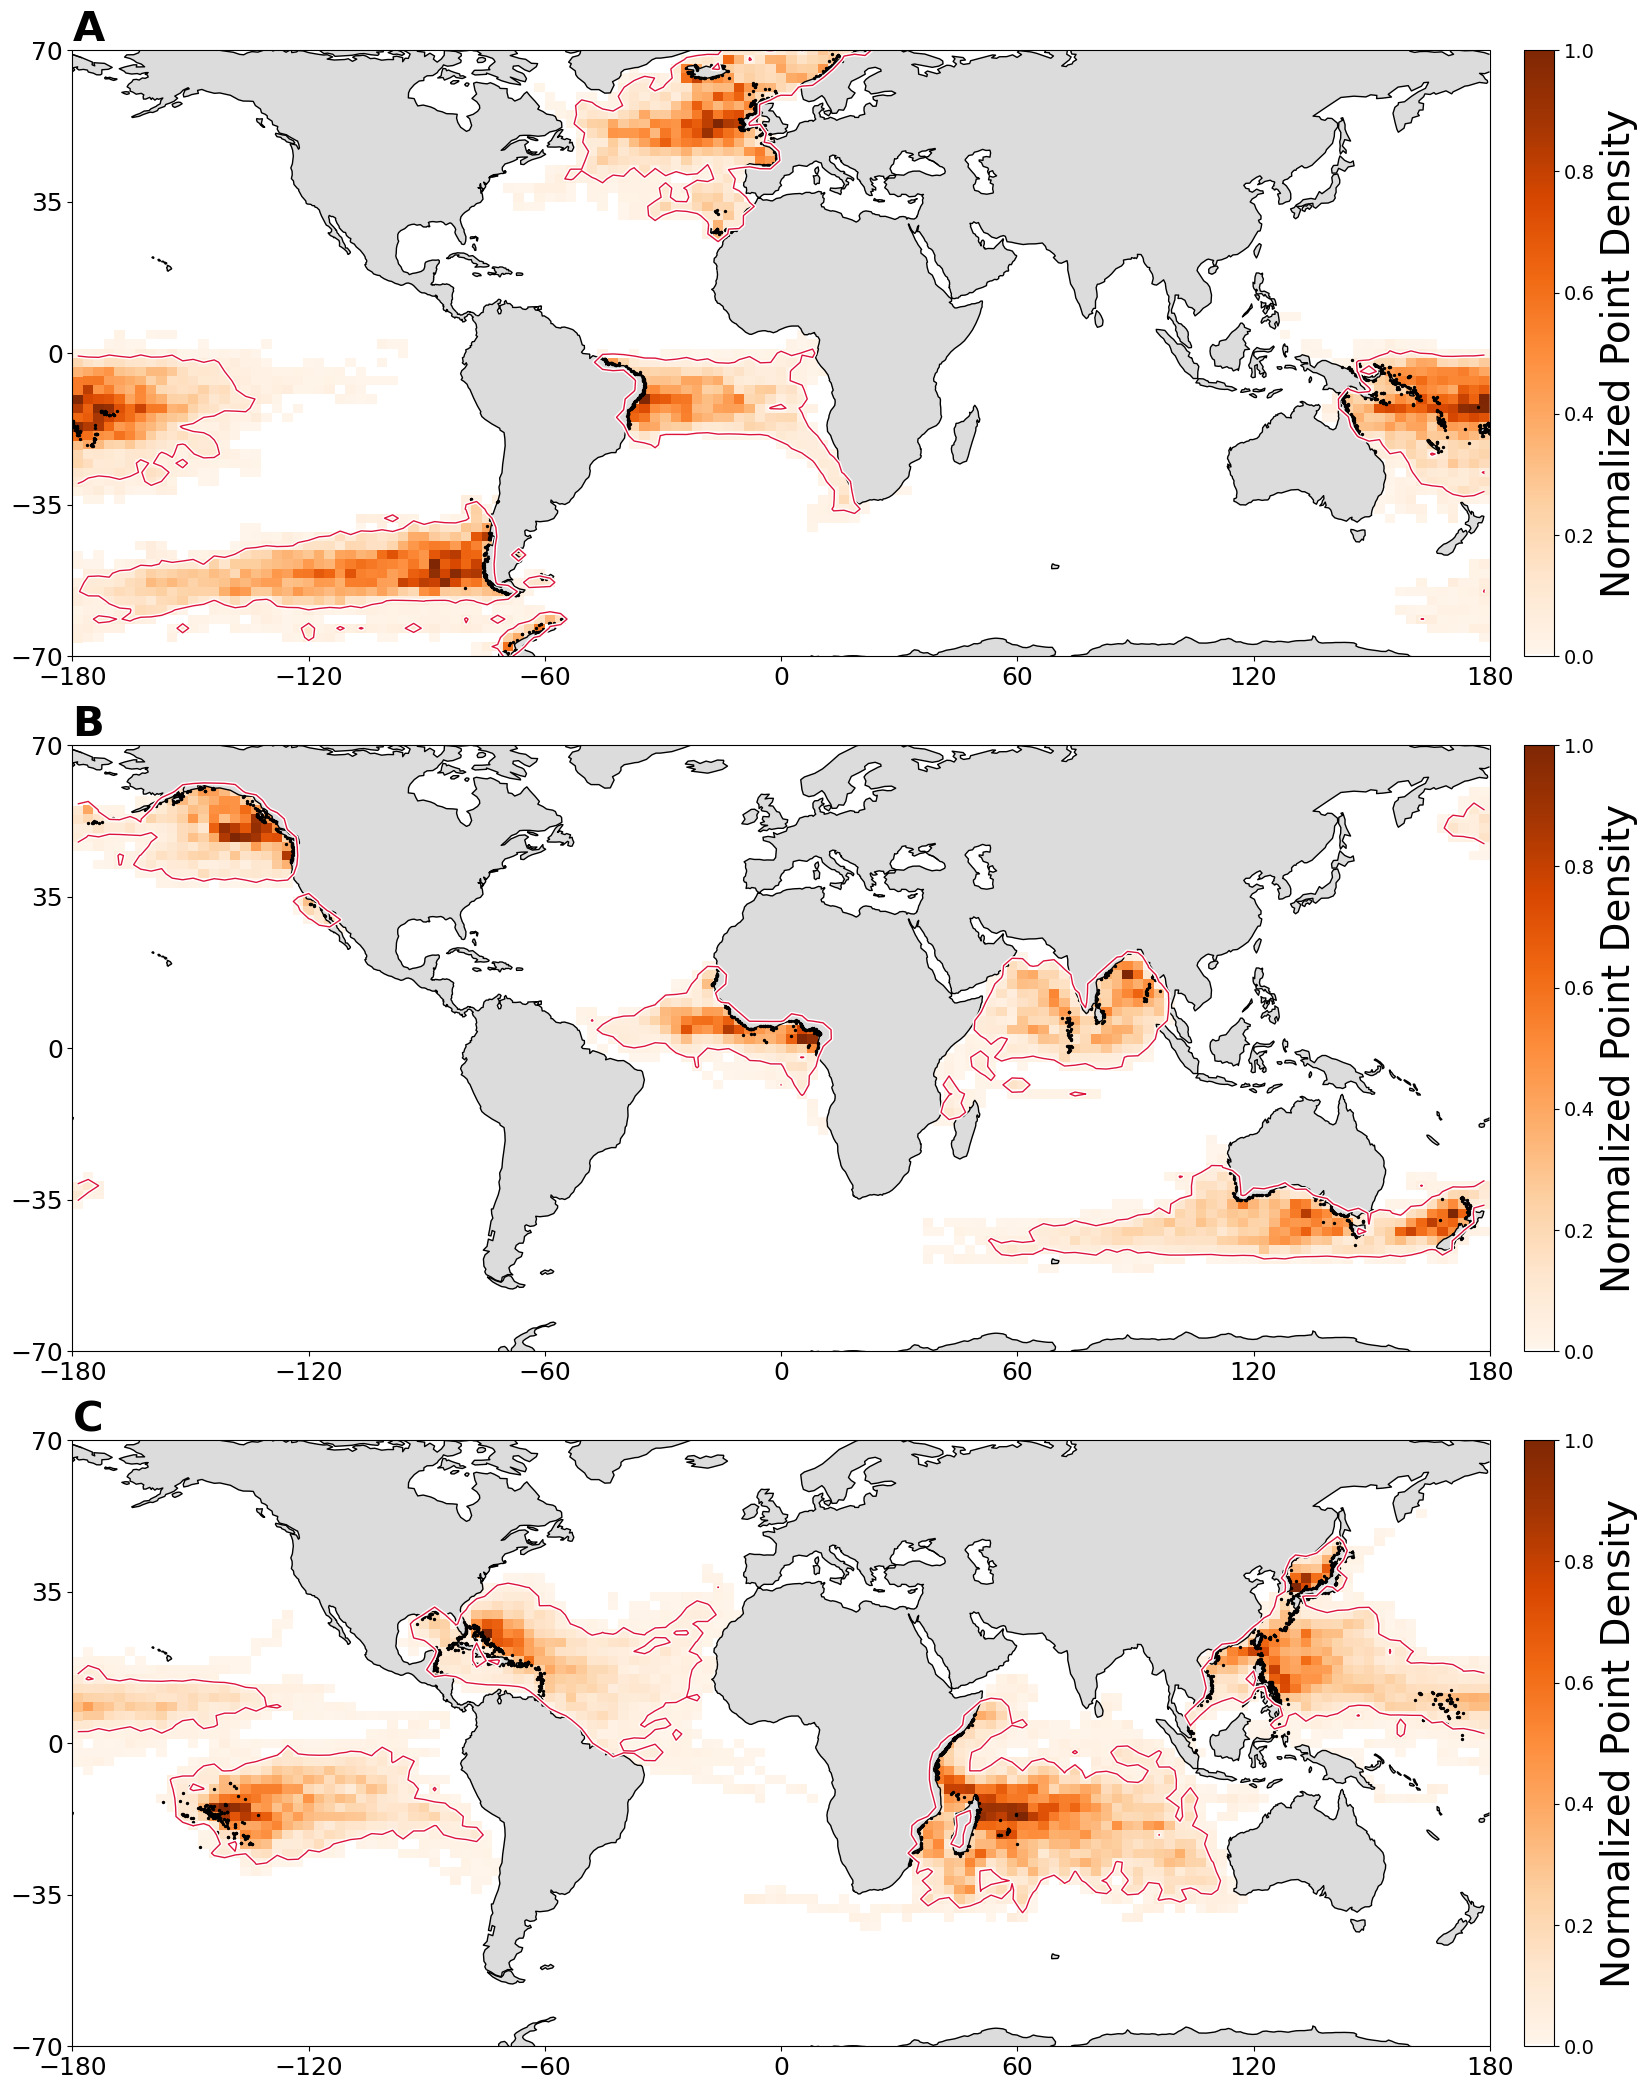

In [37]:

# Define combinations of watersheds
combinations = [
    (['SW_Pacific', 'SW_Atlantic', 'Southern_Ocean_S_America', 'NE_Atlantic'], watersheds),
    (['N_Pacific', 'N_Indian', 'SE_Atlantic', 'Southern_Ocean_Oceania'], watersheds),
    (['W_Pacific', 'NW_Atlantic', 'Central_Pacific', 'W_Indian'], watersheds),
]
fig, axes = plt.subplots(3, 1, figsize=(18, 21),
                         subplot_kw={'projection': ccrs.PlateCarree()})

labels = ['A', 'B', 'C']

def process_watersheds_on_ax(ax, watershed_names, watersheds, label):

    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)

    cmap = plt.colormaps["Oranges"].resampled(256)

    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]
    custom_cmap = LinearSegmentedColormap.from_list("custom_oranges", new_colors)

    heatmap_data_normalized12_list = np.zeros((85, 135))

    for watershed_name in watershed_names:
        filtered_data_12m = preprocess_data(year_to_beach(watersheds[watershed_name]))

        latitudes12 = filtered_data_12m['lat'].values
        longitudes12 = filtered_data_12m['lon'].values

        heatmap_data12, _, _ = np.histogram2d(
            latitudes12, longitudes12,
            bins=[lat_bins, lon_bins], density=True
        )

        heatmap_data_normalized12 = (
            heatmap_data12 - np.min(heatmap_data12)
        ) / (np.max(heatmap_data12) - np.min(heatmap_data12))

        # contours
        ax.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='white', linewidths=3,
            transform=ccrs.PlateCarree()
        )

        ax.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='crimson', linewidths=1,
            transform=ccrs.PlateCarree()
        )

        heatmap_data_normalized12_list += heatmap_data_normalized12

    # heatmap
    mesh = ax.pcolormesh(
        lon_centers_cluster, lat_centers_cluster,
        heatmap_data_normalized12_list,
        cmap=custom_cmap,
        transform=ccrs.PlateCarree()
    )

    # land + coast
    world.plot(ax=ax, color='gainsboro', edgecolor='none')
    ax.coastlines(color='black')

    # beaching points
    for watershed_name in watershed_names:
        ax.scatter(
            beaching_dict[watershed_name]['lon'],
            beaching_dict[watershed_name]['lat'],
            color='k', s=2
        )

    ax.set_aspect('auto')
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])

    # panel label
    ax.set_title(label, loc='left', fontweight='bold', fontsize=30)

    # individual colorbar
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label('Normalized Point Density', size=28)


# --- run panels ---
for ax, (watershed_names, watersheds), label in zip(axes, combinations, labels):
    process_watersheds_on_ax(ax, watershed_names, watersheds, label)

plt.tight_layout()
plt.savefig("figs/watersheds", dpi=300)
plt.show()


In [38]:
# Plot all trajectories of all watersheds:

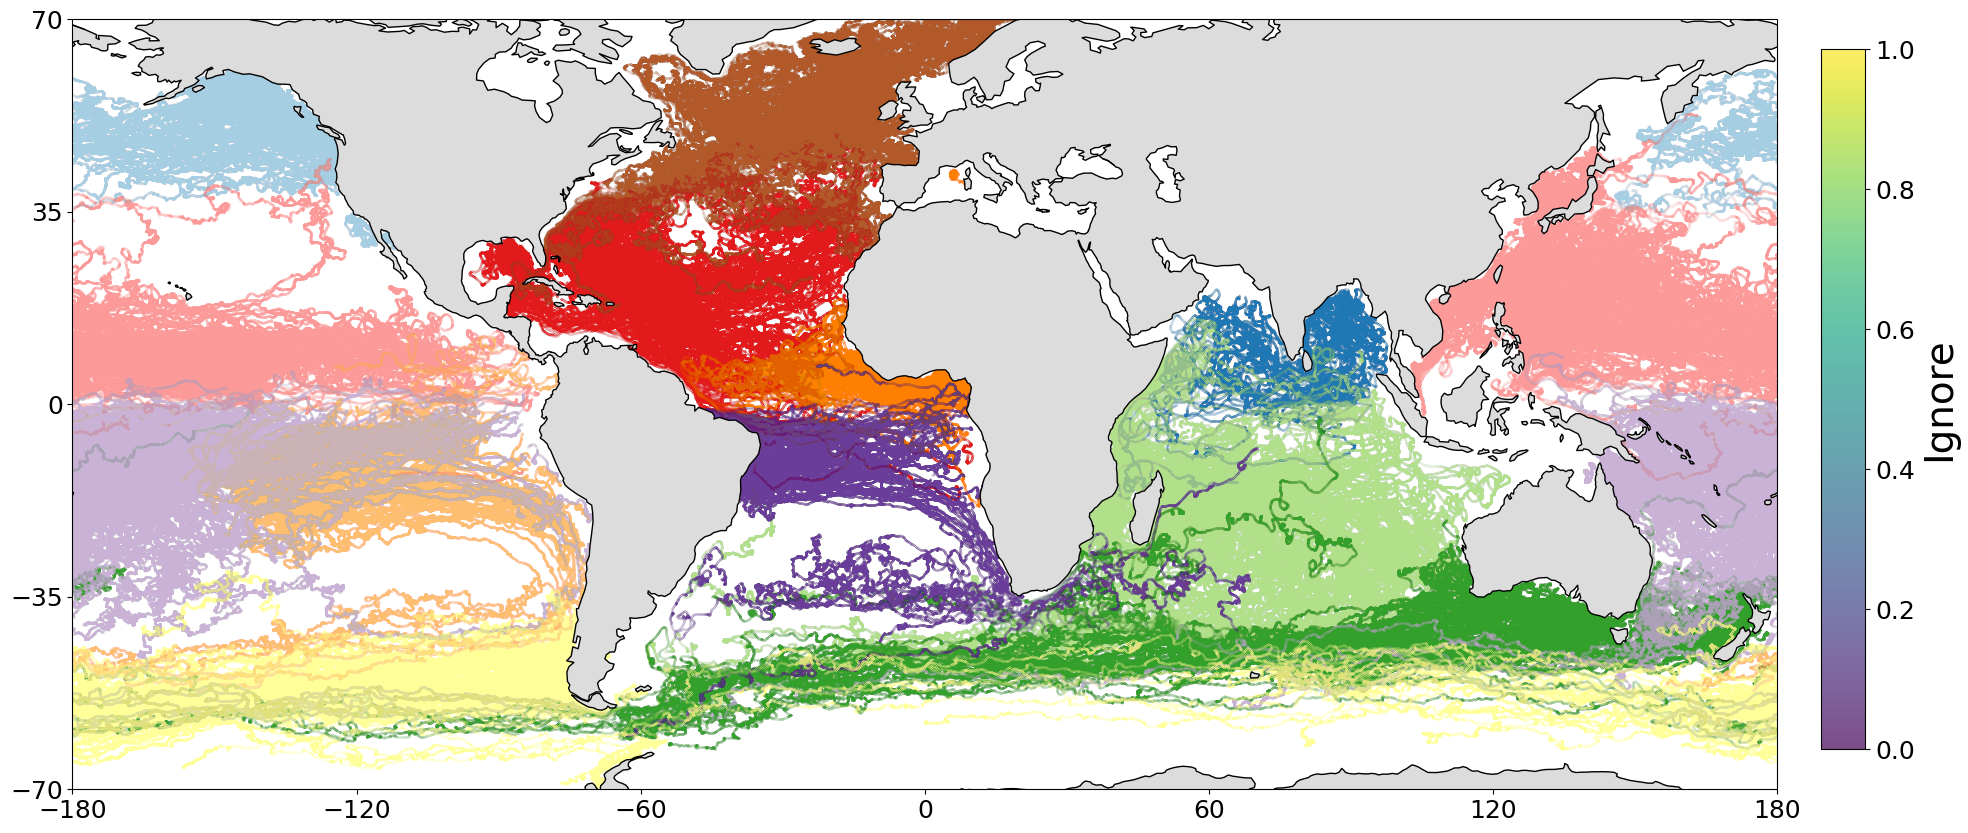

In [39]:
# trajectories
fig = plt.figure(figsize=(22, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
ax.set_ylim(-70, 70)

ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax.set_yticks([-70, -35, 0, 35, 70])

paired_cmap = plt.get_cmap('Paired')
colors = paired_cmap(np.linspace(0, 1, 12))

watershed_colors = {str(w): colors[i] for i, w in enumerate(watersheds)}
for watershed in watersheds:
    color_indice = watershed_colors[str(watershed)]
    scatter1 = plt.scatter(
        watersheds[str(watershed)]['lon'],
        watersheds[str(watershed)]['lat'],
        marker='o',
        color=color_indice,
        alpha=0.7,
        s=0.001)

ax.coastlines(color = 'black')
    
# Plot the land polygons
world.plot(ax=ax, color='gainsboro', edgecolor='none')
ax.set_aspect('auto')
ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(cax = cbar_ax, label='Normalized Point Density')
cbar.ax.tick_params(labelsize=18)  # Increase tick size
cbar.set_label('Ignore', size=28)  # Increase label text size
    

#plt.savefig("ocean_delineation_trajectories", dpi=300)
#plt.close(fig)
plt.show()


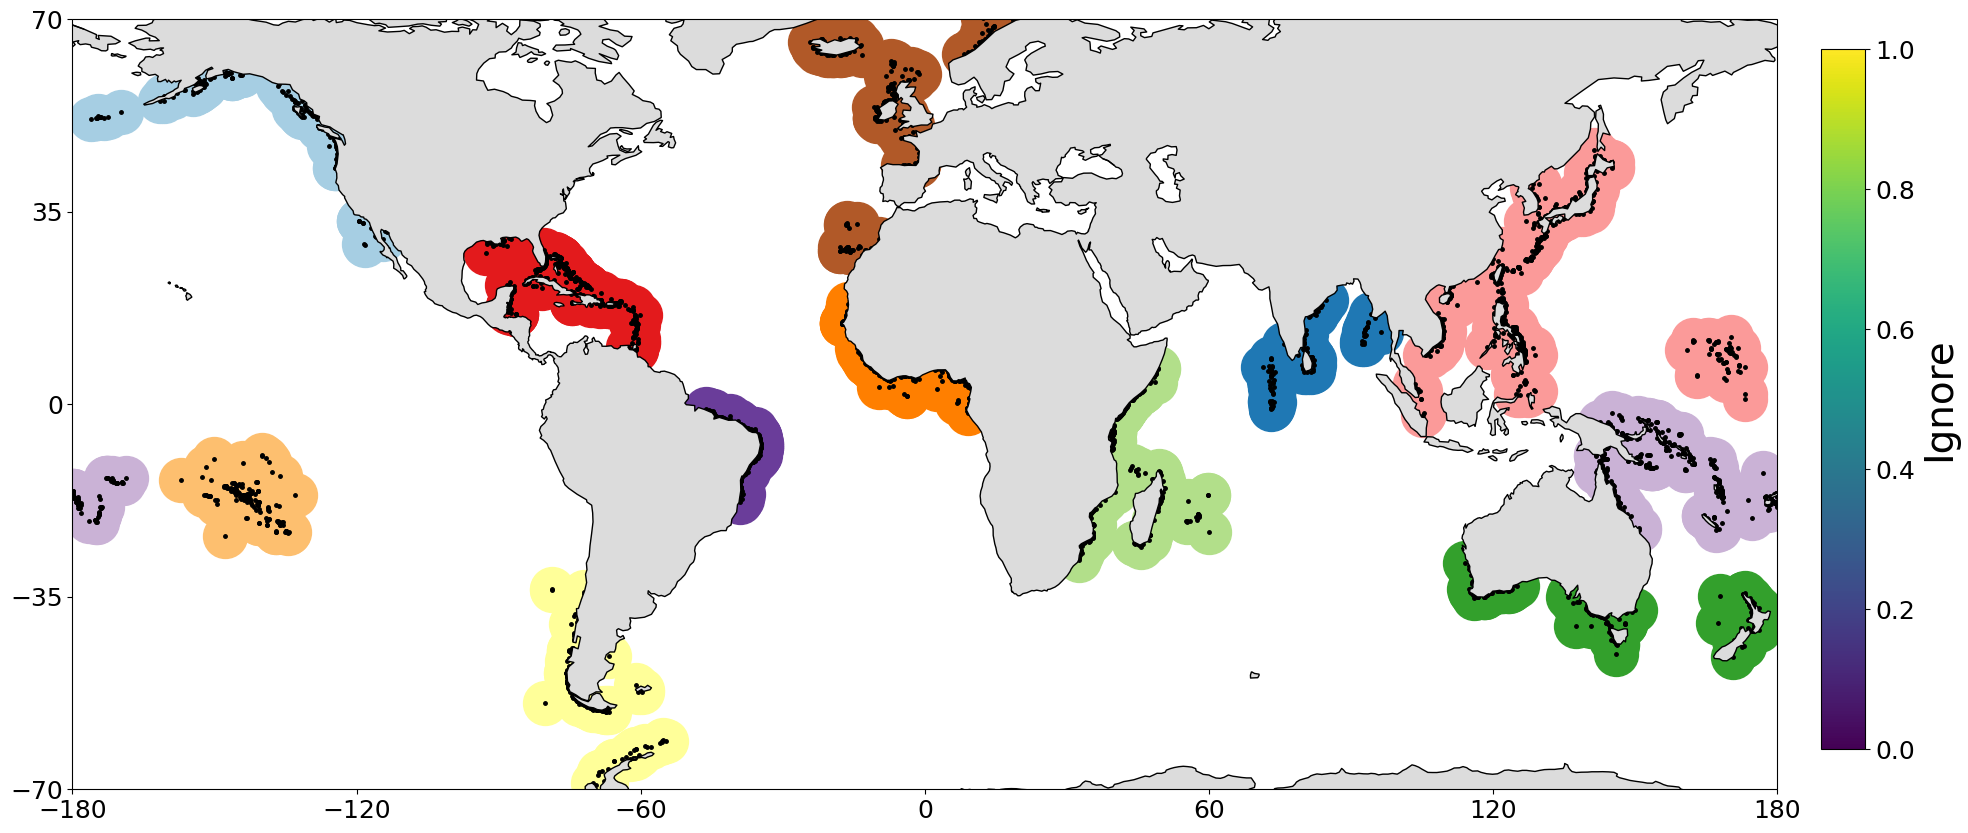

In [40]:
# beaching points and noise
fig = plt.figure(figsize=(22, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
ax.set_ylim(-70, 70)

ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
ax.set_yticks([-70, -35, 0, 35, 70])

paired_cmap = plt.get_cmap('Paired')
colors = paired_cmap(np.linspace(0, 1, 12))

watershed_colors = {str(w): colors[i] for i, w in enumerate(watersheds)}

for watershed in watersheds:
    color_indice = watershed_colors[str(watershed)]
    scatter2 = plt.scatter(
        beaching_dict[str(watershed)]['lon'], 
        beaching_dict[str(watershed)]['lat'], 
        marker='o',
        color=color_indice,
        s=1000)
    
#plt.scatter(beaching_coooords[1], beaching_coooords[0], color = 'gray', linewidth = 1) 
    
for watershed in watersheds:
    scatter2 = plt.scatter(
        beaching_dict[str(watershed)]['lon'], 
        beaching_dict[str(watershed)]['lat'], 
        marker='.',
        color='k',
        s=25)


ax.coastlines(color = 'black')
    
# Plot the land polygons
world.plot(ax=ax, color='gainsboro', edgecolor='none')
ax.set_aspect('auto')
ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = plt.colorbar(cax = cbar_ax, label='Normalized Point Density')
cbar.ax.tick_params(labelsize=18)  # Increase tick size
cbar.set_label('Ignore', size=28)  # Increase label text size
#plt.savefig("ocean_delineation_beaching", dpi=300)
#plt.close(fig)
plt.show()

Colorbars in the above 2 plots ensure aspect ratios that match other plots with colorbars

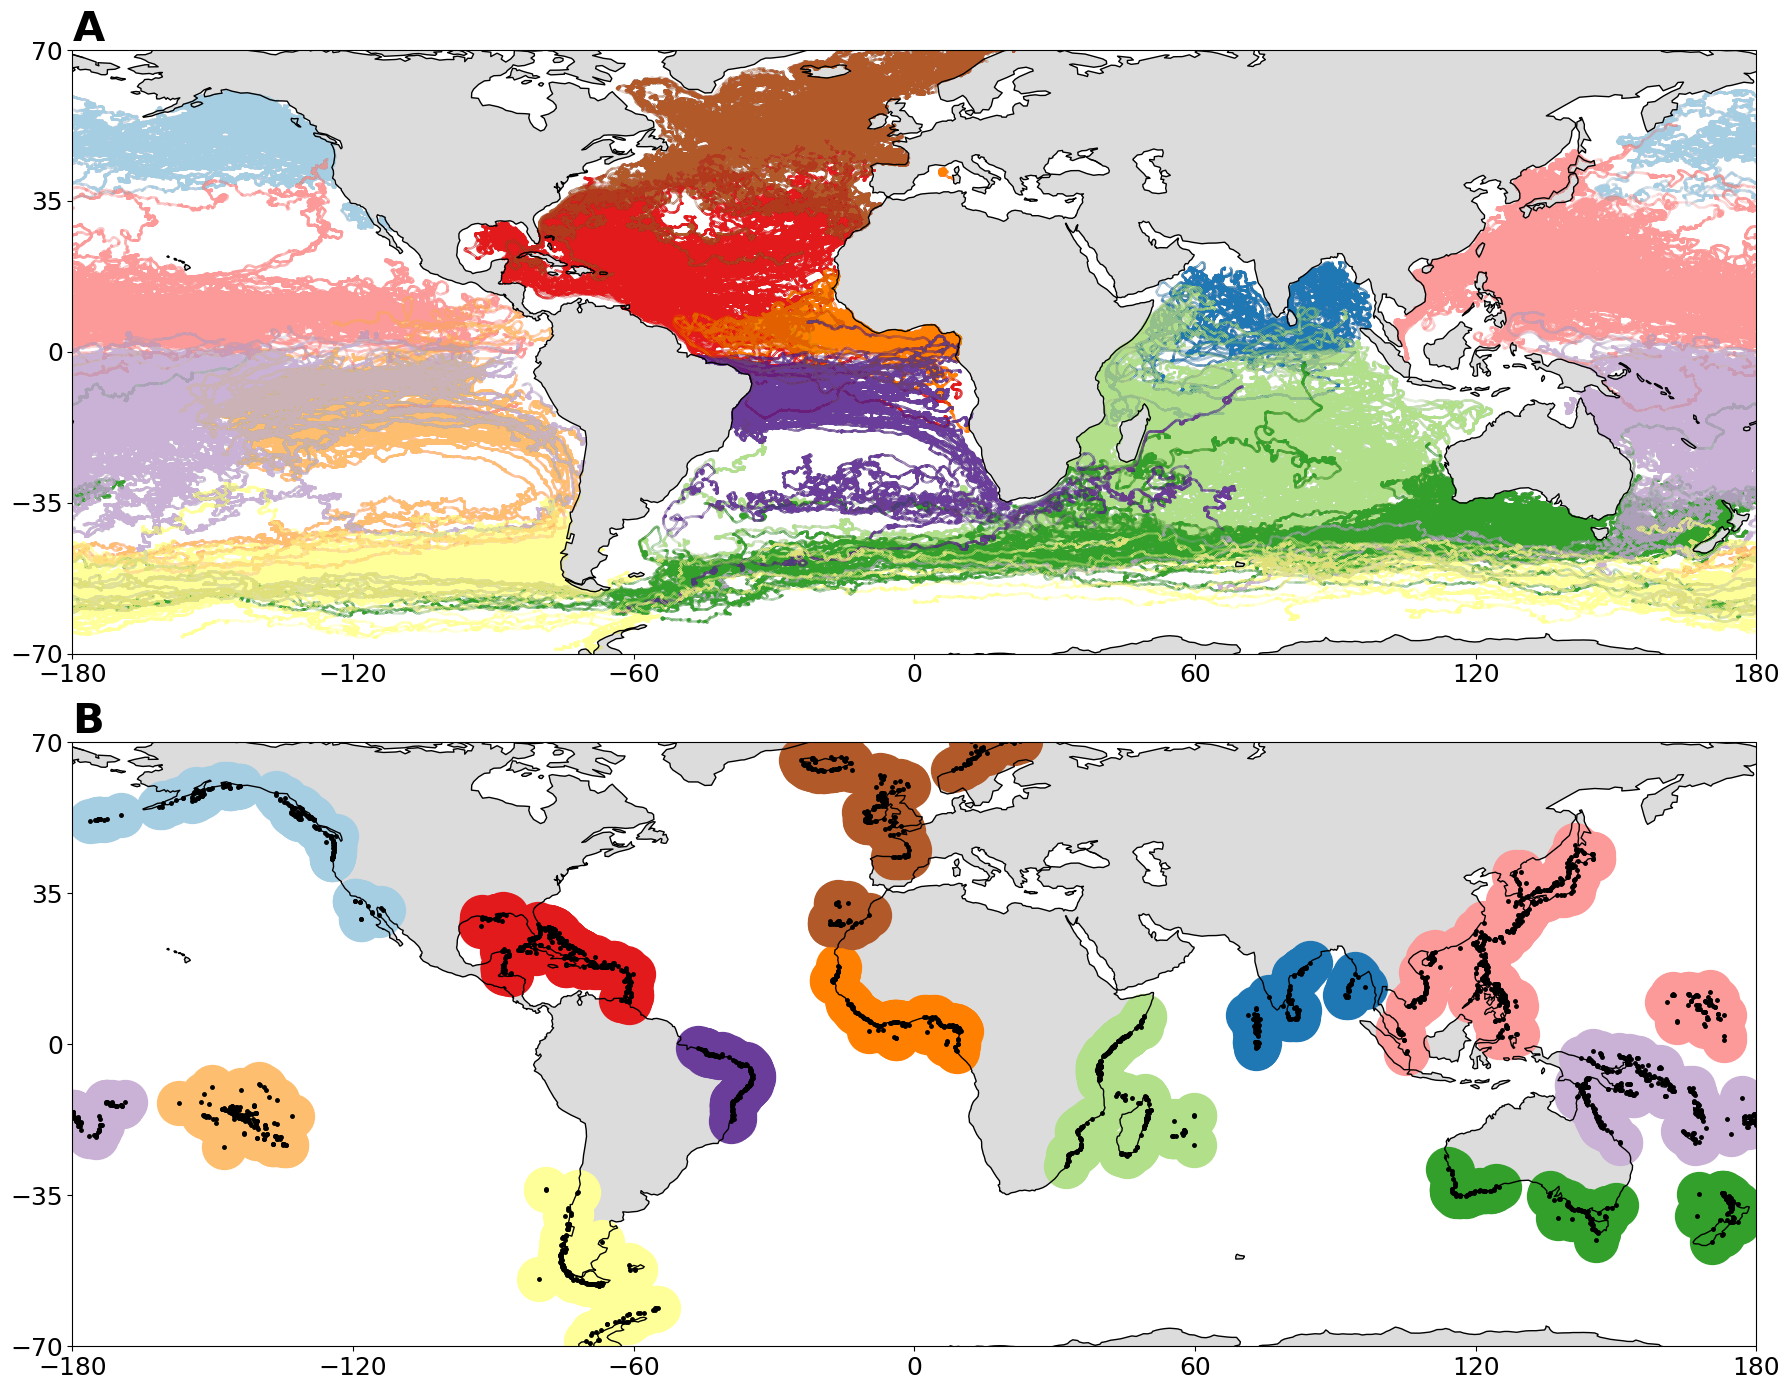

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 14),
                               subplot_kw={'projection': ccrs.PlateCarree()})

paired_cmap = plt.get_cmap('Paired')
colors = paired_cmap(np.linspace(0, 1, 12))
watershed_colors = {str(w): colors[i] for i, w in enumerate(watersheds)}

for ax in (ax1, ax2):
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])
    world.plot(ax=ax, color='gainsboro', edgecolor='none')
    ax.coastlines(color='black')
    ax.set_aspect('auto')

# --- A: trajectories ---
for watershed in watersheds:
    color_indice = watershed_colors[str(watershed)]
    ax1.scatter(
        watersheds[str(watershed)]['lon'],
        watersheds[str(watershed)]['lat'],
        marker='o',
        color=color_indice,
        alpha=0.7,
        s=0.001
    )

ax1.set_title('A', fontweight='bold', loc='left')

# --- B: beaching points ---
for watershed in watersheds:
    color_indice = watershed_colors[str(watershed)]
    ax2.scatter(
        beaching_dict[str(watershed)]['lon'], 
        beaching_dict[str(watershed)]['lat'], 
        marker='o',
        color=color_indice,
        s=1000
    )

for watershed in watersheds:
    ax2.scatter(
        beaching_dict[str(watershed)]['lon'], 
        beaching_dict[str(watershed)]['lat'], 
        marker='.',
        color='k',
        s=25
    )

ax2.set_title('B', fontweight='bold', loc='left')

# # --- Invisible colorbars to fix layout ---
# import matplotlib as mpl

# dummy = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(0, 1))
# dummy.set_array([])

# for ax in (ax1, ax2):
#     cbar = fig.colorbar(dummy, ax=ax, orientation='vertical', pad=0.02)
#     cbar.ax.set_alpha(0)              # fully transparent
#     cbar.outline.set_visible(False)
#     cbar.set_ticks([])

plt.tight_layout()
plt.savefig("figs/ocean_delineation_beaching", dpi=300)
plt.show()

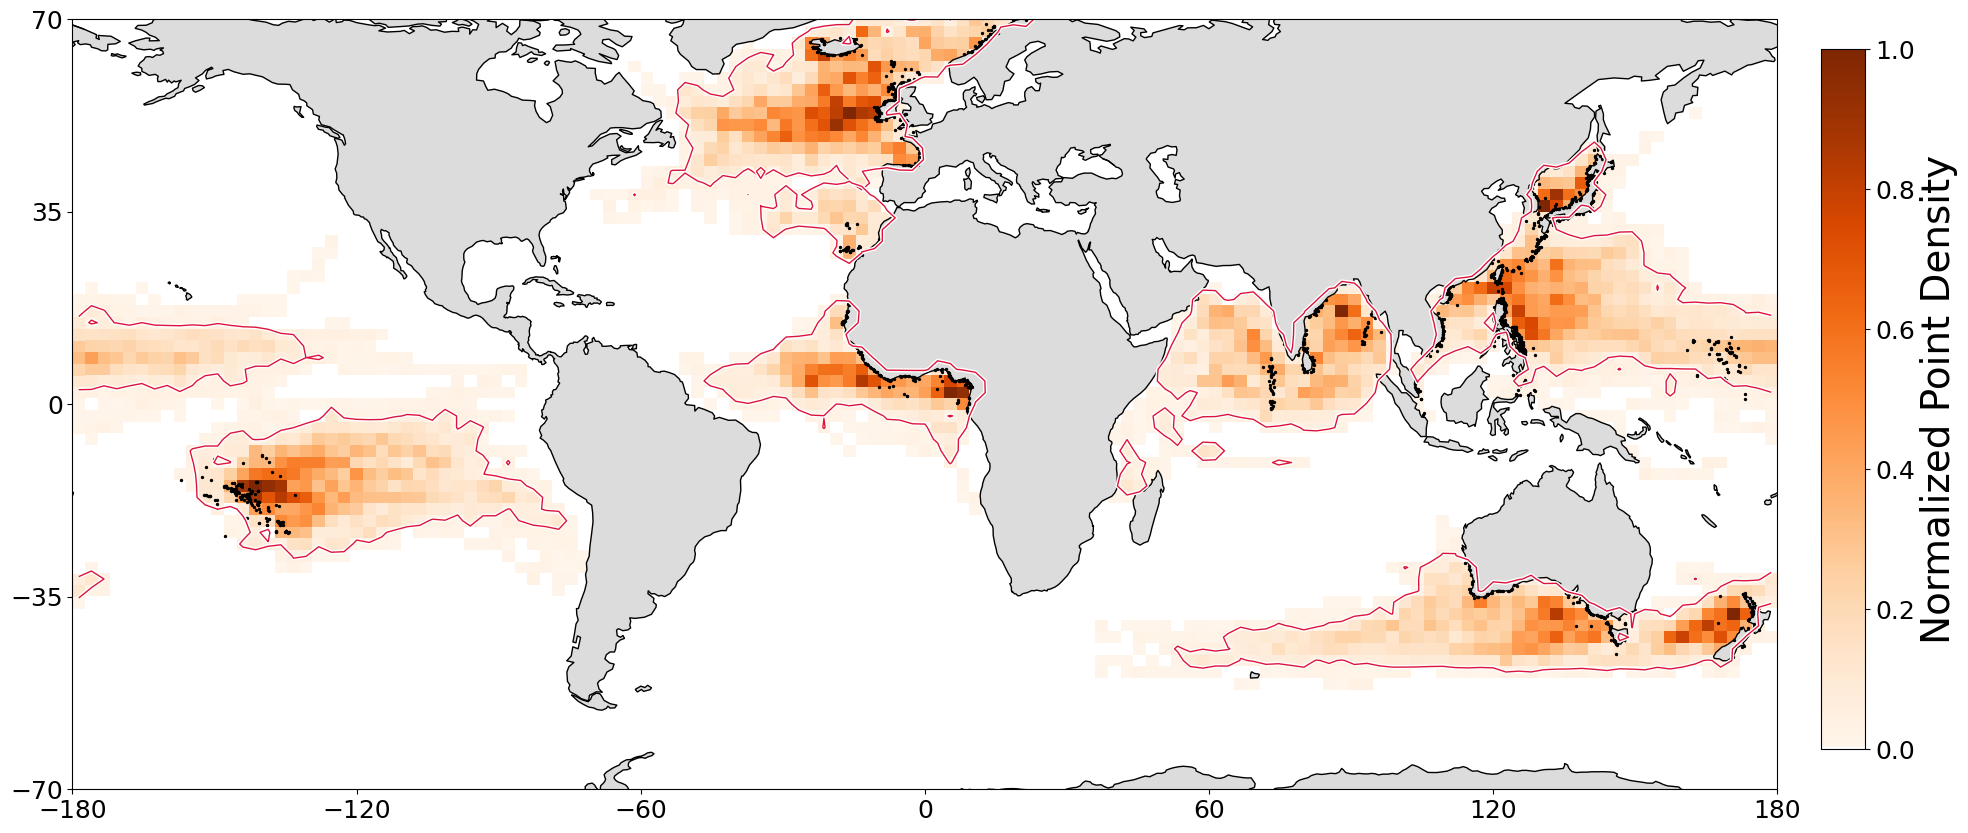

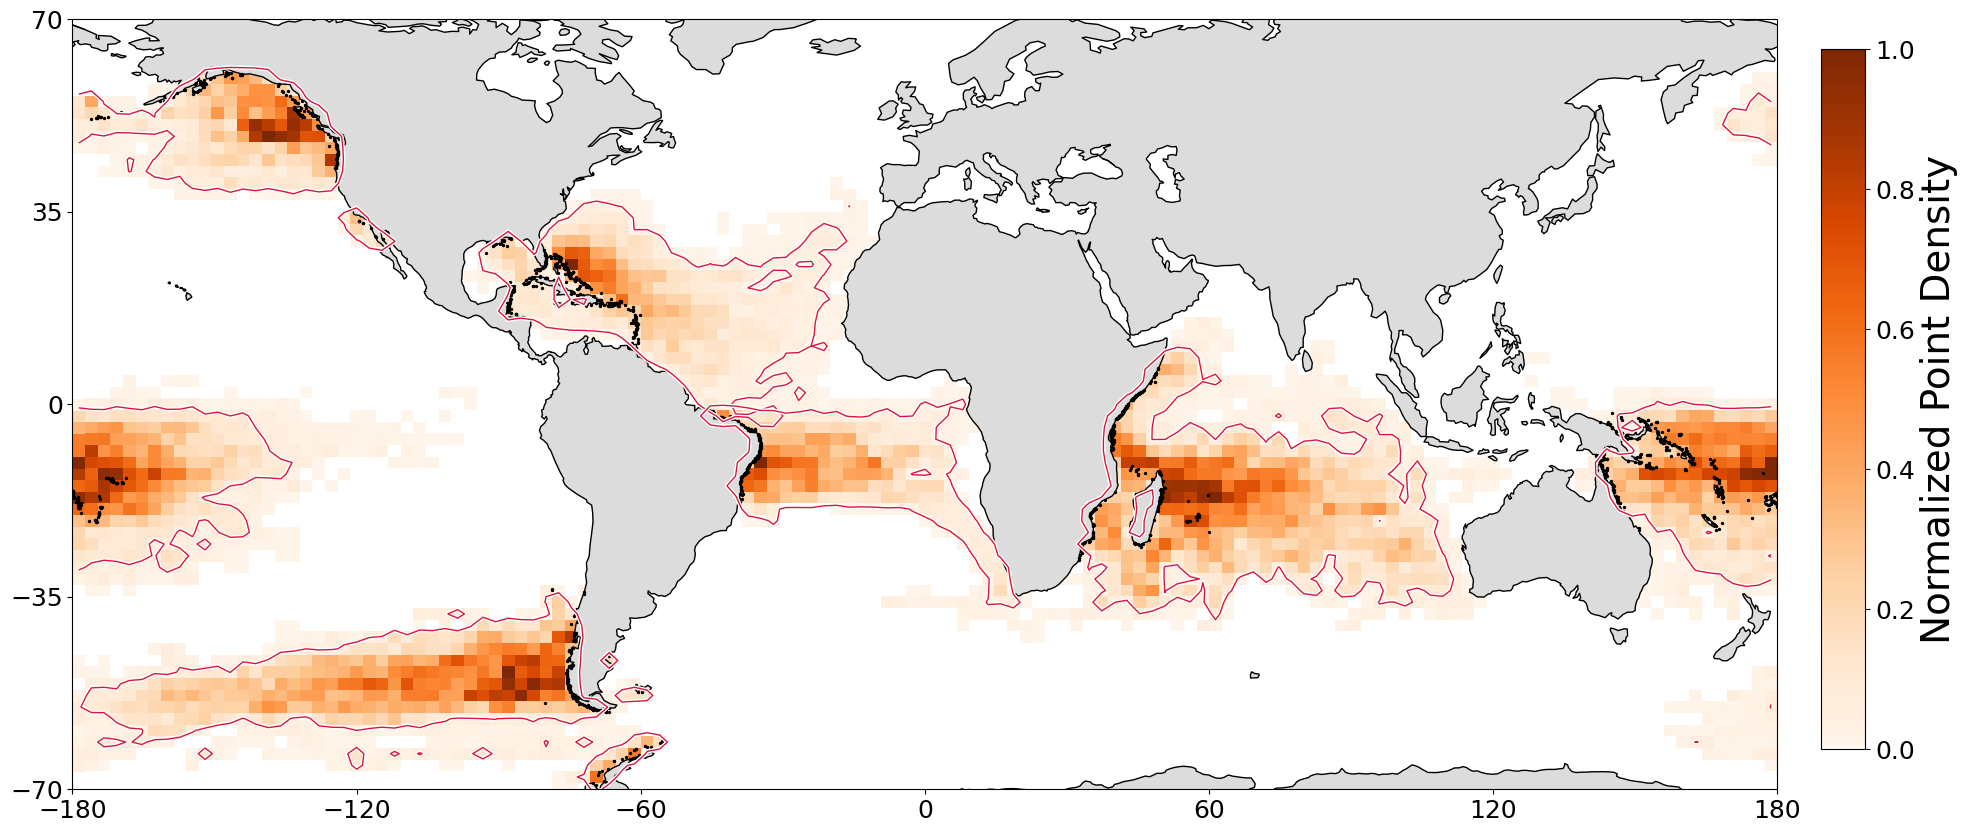

In [36]:
# Load world shapefile
world = gpd.read_file(geodatasets.data.naturalearth.land.path)


#grid for the heatmap
n_lons, n_lats = 135, 85  # Number of grid cells
lon_bins = np.linspace(-180, 180, n_lons + 1)
lat_bins = np.linspace(-90, 90, n_lats + 1)
lon_centers_cluster = (lon_bins[1:] + lon_bins[:-1]) / 2
lat_centers_cluster = (lat_bins[1:] + lat_bins[:-1]) / 2

# filter data to within a year
def year_to_beach(cluster):
    year = 31536000  # Number of seconds in 1 year
    # Make a copy of the filtered cluster to avoid the warning
    if (cluster['time_to_beach'] <= year).any():
        filtered_cluster = cluster[cluster['time_to_beach'] <= year].copy()
    return filtered_cluster

def preprocess_data(df):
    # Ensure df is modified safely with .loc and make a copy if needed
    df.loc[:, 'lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df.loc[:, 'lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df.dropna(subset=['lat', 'lon'], inplace=True)
    
    return df

def process_watersheds(watershed_names, watersheds):
    # Create a figure for the plot
    fig = plt.figure(figsize=(22, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -70, 70], crs=ccrs.PlateCarree())
    ax.set_ylim(-70, 70)
    # Adjust the position of the plot box for better width control
   # ax.set_position([0.05, 0.05, 0.9, 0.9])  # [left, bottom, width, height]

    cmap = plt.colormaps["Oranges"].resampled(256)

    # Modify the colormap by adding white at the lowest end
    new_colors = cmap(np.linspace(0, 1, 256))
    new_colors[0] = [1, 1, 1, 1]  # Set the first color to white (R, G, B, Alpha)

    # Create a new colormap with the modified colors
    custom_cmap = LinearSegmentedColormap.from_list("custom_oranges", new_colors)
    
    contour_handles = []
    
    heatmap_data_normalized12_list = np.zeros((85, 135))
    for j, watershed_name in enumerate(watershed_names):
        # Filter the data for 1 year (12 months) using the new function
        filtered_data_12m = preprocess_data(year_to_beach(watersheds[watershed_name]))
       # print(filtered_data_12m)
        
        latitudes12 = list(filtered_data_12m['lat'].values)
        longitudes12 = list(filtered_data_12m['lon'].values)

        # Calculate the 2D histogram (density plot) of point density for 12 months
        heatmap_data12, _, _ = np.histogram2d(latitudes12, longitudes12, bins=[lat_bins, lon_bins], density=True)

        # Normalize the 12-month data
        heatmap_data_normalized12 = (heatmap_data12 - np.min(heatmap_data12)) / (np.max(heatmap_data12) - np.min(heatmap_data12))

        # Plot contours for the normalized data
        linewidths = [3]
      #  linestyless = ['-', '--', ':', '-.']
        contour = plt.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            #[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)], 
            colors='white', linewidths=linewidths[0], 
            transform=ccrs.PlateCarree()
        )
      #  contour_handles.append(contour.collections[0])
        
        # Add additional contour with crimson color
        contour = plt.contour(
            lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12,
            levels=[np.mean(heatmap_data_normalized12) + np.std(heatmap_data_normalized12)],
            colors='crimson', linestyles='solid', linewidths=1,
            transform=ccrs.PlateCarree()
        )
       # contour_handles.append(contour.collections[0])

        heatmap_data_normalized12_list += heatmap_data_normalized12
    # Plot the filled contour for normalized heatmaps
    mesh = ax.pcolormesh(lon_centers_cluster, lat_centers_cluster, heatmap_data_normalized12_list, cmap=custom_cmap, transform=ccrs.PlateCarree())

    # Plot the land polygons
    world.plot(ax=ax, color='gainsboro', edgecolor='none')

    # Plot legend
    contour_handles = [
        Line2D([0], [0], color='lightcoral', linewidth=2)
        for watershed in watershed_names
    ]

    for watershed_name in watershed_names:
        plt.scatter(beaching_dict[watershed_name]['lon'], beaching_dict[watershed_name]['lat'], 
                    color='k', s=2)
 #   beach_coords_handle = mlines.Line2D([], [], color='k', marker='o', linestyle='None', markersize=10, label='beach coords')
#
   # ax.legend(contour_handles + [beach_coords_handle], watershed_names + ['beaching locations'], loc='upper right', bbox_to_anchor=(0.83, 1.02), fontsize=18)

    # Add colorbar with increased tick size and label text size
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = plt.colorbar(mesh, cax = cbar_ax, label='Normalized Point Density')
    cbar.ax.tick_params(labelsize=18)  # Increase tick size
    cbar.set_label('Normalized Point Density', size=28)  # Increase label text size
    
    ax.set_aspect('auto')
    
    ax.coastlines(color = 'black')
    
    ax.set_xticks([-180, -120, -60, 0, 60, 120, 180])
    ax.set_yticks([-70, -35, 0, 35, 70])
    
    #plt.savefig(f"final_watersheds/watersheds_poster_{'_'.join(watershed_names)}.png")
    
    
# Define combinations of watersheds
combinations = [
    (['NE_Atlantic','N_Indian', 'SE_Atlantic', 'Southern_Ocean_Oceania','W_Pacific','Central_Pacific'], watersheds),
    (['NW_Atlantic', 'W_Indian','SW_Pacific', 'SW_Atlantic', 'N_Pacific', 'Southern_Ocean_S_America'], watersheds)
]

for watershed_names, watersheds in combinations:
    process_watersheds(watershed_names, watersheds)


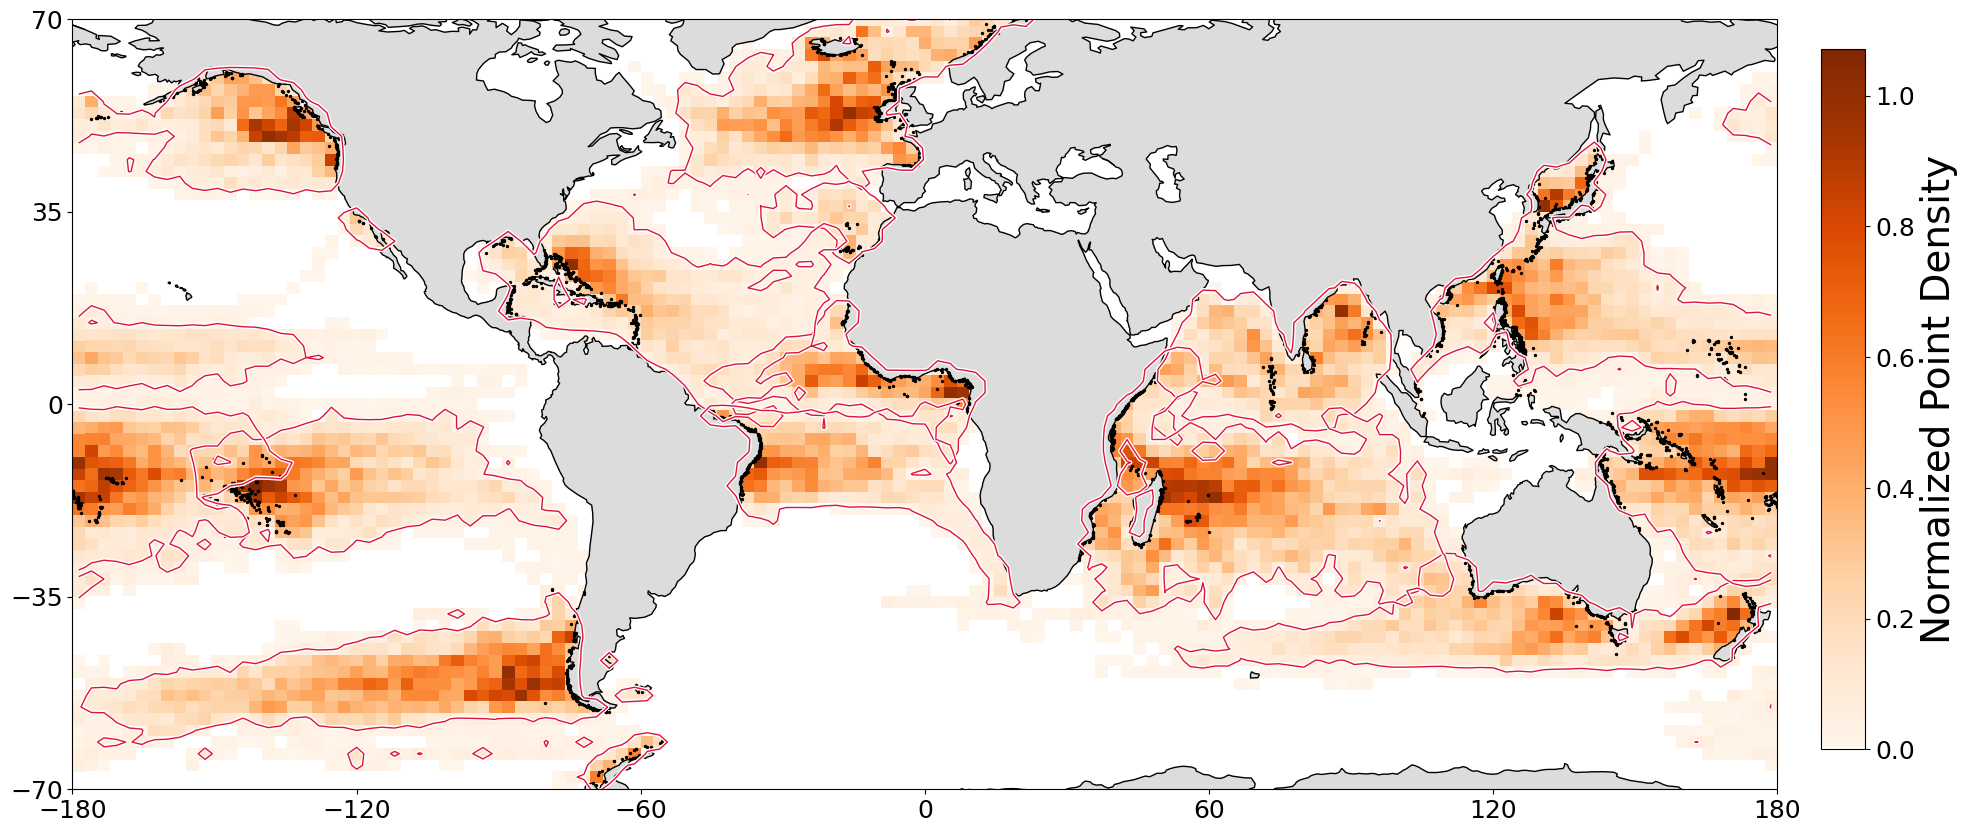